# Анализ платежей донаторов БФ «Марафон добра»

**Заказчик:** благотворительный фонд «Марафон добра» (марафондобра.рф) — адресная помощь тяжелобольным детям. Регулярные пожертвования принимаются в виде ежемесячных подписок с банковской карты через CloudPayments.

**Задача проекта:** провести аналитическое исследование исторических данных о пожертвованиях: определить закономерности поведения донаторов, оценить эффективность регулярных подписок и сформулировать практические рекомендации для роста регулярных пожертвований и удержания донаторов.

**Данные:** выгрузка подписок CloudPayments, 42 806 подписок за период 08.04.2019 – 18.06.2026.
- Одна строка = подписка (не платёж).
- Разовые пожертвования и другие каналы (SMS, переводы, QR) в выгрузку не входят — выводы относятся к регулярным карточным пожертвованиям.

**Содержание:**
1. Загрузка и первичный осмотр
2. Проверки качества данных
3. Очистка: тесты, крупные суммы, аномальные плательщики
4. Динамика привлечения
5. Длительность жизни подписки
6. Когортный анализ удержания
7. Survival-анализ (Каплан–Майер)
8. Структура оттока
9. RFM-сегментация донаторов
10. ABC-анализ (Парето)
11. SQL-слой: перекрёстная проверка
12. Экспорт витрин для Power BI
13. Выводы и рекомендации


In [1]:
# Библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from lifelines import KaplanMeierFitter          # survival-анализ (раздел 7)
from lifelines.statistics import logrank_test
# SQL-движок (duckdb) подключается в разделе 11

from pathlib import Path

# Пути проекта: всё относительно папки, из которой запущен ноутбук
BASE_DIR = Path.cwd()
DATA_FILE = BASE_DIR / "encoded_Подписки Cloud Payments 18-06.csv"
POWERBI_DIR = BASE_DIR / "powerbi_data"

# Доменные константы: статусы подписки (семантика - в разделе 2)
ALIVE_STATUSES = ["Активна", "Просрочена", "В ожидании"]
DEAD_STATUSES = ["Отменена", "Отклонена"]

# Формат дат в выгрузке CloudPayments
DATE_FORMAT = "%d.%m.%Y %H:%M:%S"

# Дата выгрузки - срез данных; месяц среза производен от неё
CUTOFF = pd.Timestamp("2026-06-18 23:59:59")
CUTOFF_M = CUTOFF.to_period("M")


## 1. Загрузка и первичный осмотр

Технические особенности файла: UTF-8 с BOM, разделитель `;`, десятичная запятая, даты в формате `ДД.ММ.ГГГГ ЧЧ:ММ:СС`.

Назначение столбцов (подтверждено заказчиком): 
- `ID` — идентификатор подписки; 
- `Дата/время создания` — оформление (сопровождается первой попыткой списания); 
- `Статус` — текущее состояние подписки; 
- `Сумма` — ежемесячный платёж; 
- `ID плательщика` — зашифрованный email, стабилен при смене карты (один человек = один ID); 
- `Кол-во платежей` — число состоявшихся списаний; далее даты последнего/следующего платежа. 
- `Валюта`, `Периодичность`, `Описание` — константы, в анализе не используются.

Загрузку оформляем функцией `load_data()`: чтение CSV (разделитель `;`, десятичная запятая) и приведение дат к `datetime`. Смотрим количество строк по статусам и первые строки таблицы.

In [2]:
def load_data(path):
    """Читает выгрузку CloudPayments и приводит колонки дат к datetime."""
    df = pd.read_csv(path, sep=";", encoding="utf-8-sig", decimal=",")
    for col in ["Дата/время создания", "Дата/время последнего платежа",
                "Дата/время следующего платежа"]:
        df[col] = pd.to_datetime(df[col], format=DATE_FORMAT)
    return df

subs = load_data(DATA_FILE)
display(subs.head())
print("Строки по статусам платежа:")
display(subs["Статус"].value_counts())


,ID,Дата/время создания,Статус,Сумма,Валюта,Периодичность,Описание,ID плательщика,Кол-во платежей,Дата/время последнего платежа,Дата/время следующего платежа
0,sc_5fd0defafe7ff468dbd3257da445c,2026-06-18 08:39:25,Активна,1000.0,₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_41ef2e0fdbe2,0,NaT,2026-07-18 08:39:24
1,sc_fb4115049bb199106b401cb66c8bb,2026-06-17 20:57:39,Активна,100.0,₽,Раз в месяц,Благотворительное пожертвование,PID_34f44fc59dc0,0,NaT,2026-07-17 20:57:39
2,sc_1dad551bda204a1c1ce3a60573458,2026-06-17 20:35:25,Активна,100.0,₽,Раз в месяц,Благотворительное пожертвование,PID_1070551ebf1b,0,NaT,2026-07-17 20:35:25
3,sc_9c512c6a7880f7cceb309c654c7ef,2026-06-16 20:37:05,Активна,500.0,₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_cd9879f83789,0,NaT,2026-07-16 20:37:05
4,sc_b1911b7fb5bd247c6c40f25707aed,2026-06-16 15:43:23,Активна,100.0,₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_6bf236df9e02,0,NaT,2026-07-16 15:43:22


Строки по статусам платежа:


Статус
Отменена      19259
Отклонена     17025
Активна        4827
Просрочена     1643
В ожидании       52
Name: count, dtype: int64

Информация по столбцам и типам данных:

In [3]:
subs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42806 entries, 0 to 42805
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   ID                             42806 non-null  object        
 1   Дата/время создания            42806 non-null  datetime64[ns]
 2   Статус                         42806 non-null  object        
 3   Сумма                          42806 non-null  float64       
 4   Валюта                         42806 non-null  object        
 5   Периодичность                  42806 non-null  object        
 6   Описание                       42806 non-null  object        
 7   ID плательщика                 42806 non-null  object        
 8   Кол-во платежей                42806 non-null  int64         
 9   Дата/время последнего платежа  28537 non-null  datetime64[ns]
 10  Дата/время следующего платежа  6528 non-null   datetime64[ns]
dtypes: datetime64[n

Количество пропусков по столбцам:

In [4]:
subs.isna().sum()

ID                                   0
Дата/время создания                  0
Статус                               0
Сумма                                0
Валюта                               0
Периодичность                        0
Описание                             0
ID плательщика                       0
Кол-во платежей                      0
Дата/время последнего платежа    14269
Дата/время следующего платежа    36278
dtype: int64

Диапазон дат в данных (к `datetime` они приведены ещё при загрузке):

In [5]:
print("Даты первого и последнего события в данных:")
print(subs["Дата/время создания"].min())
print(subs["Дата/время создания"].max())


Даты первого и последнего события в данных:
2019-04-08 17:48:18
2026-06-18 08:39:25


## 2. Проверки качества данных

Проверяем согласованность полей и дубликаты. Итоги раздела:

1. **Связка «нет платежей ⇔ нет даты платежа» выполняется для всех 42 806 строк** — счётчик и дата не противоречат друг другу ни в одной записи.
2. **Дубликатов нет**: ни полных, ни по ключу `ID`, ни задвоенных подписок (один плательщик, одно и то же время создания).
3. **Артефакт выгрузки:** у 6 отменённых подписок не затёрта «дата следующего платежа» (у остальных 19 253 отменённых поле пустое) — поле используем только для активных подписок.
4. Последний месяц выгрузки (июнь 2026) неполный — 18 дней; в графиках динамики он исключается.

Проверка согласованности: поля «Кол-во платежей» и «Дата/время последнего платежа» описывают одно и то же — были ли списания. Если платежей 0, дата последнего платежа должна отсутствовать, и наоборот. Расхождение означало бы ошибку выгрузки.

In [6]:
(subs["Кол-во платежей"].eq(0) == subs["Дата/время последнего платежа"].isna()).all()

np.True_

Проверяем данные на дубли:

In [7]:
print("Количество полных дублей:")
print(subs.duplicated().sum())

Количество полных дублей:
0


In [8]:
print("Количество дублей первичного ключа:")
print(subs["ID"].duplicated().sum())

Количество дублей первичного ключа:
0


In [9]:
print("Количество задублировавшихся подписок:")
print(subs.duplicated(subset=["ID плательщика", "Дата/время создания"]).sum())

Количество задублировавшихся подписок:
0


Проверка: у завершённых (отменённых/отклонённых) подписок «Дата/время следующего платежа» должна быть пустой — следующего списания не будет. Ищем несоответствия:

In [10]:
subs[subs["Дата/время следующего платежа"].notna() & subs["Статус"].isin(DEAD_STATUSES)]

,ID,Дата/время создания,Статус,Сумма,Валюта,Периодичность,Описание,ID плательщика,Кол-во платежей,Дата/время последнего платежа,Дата/время следующего платежа
4875,sc_d298295fbe8ac0a3962544256e0af,2024-12-18 14:11:37,Отменена,500.0,₽,Раз в месяц,Благотворительное пожертвование,PID_b0157fd61ceb,14,2026-02-18 14:12:12,2026-03-18 14:11:37
5779,sc_2566d7593c3f51fc7446581411395,2024-10-31 09:10:42,Отменена,200.0,₽,Раз в месяц,Благотворительное пожертвование,PID_f26a49663169,3,2025-01-30 09:11:09,2025-02-28 09:10:41
5801,sc_68ad7c4a4e3d29ffa00149ccfb9dc,2024-10-29 14:46:49,Отменена,100.0,₽,Раз в месяц,Благотворительное пожертвование,PID_f26a49663169,3,2025-01-29 14:47:20,2025-02-28 14:46:49
8775,sc_5d22eebba78eb73ed39161f60478c,2024-06-02 04:21:03,Отменена,100.0,₽,Раз в месяц,Благотворительное пожертвование,PID_483d778a1c55,3,2024-10-02 04:21:14,2024-11-02 04:21:03
10258,sc_53ac3cea1ed2b782920350398c6a6,2024-03-14 20:02:32,Отменена,5000.0,₽,Раз в месяц,Благотворительное пожертвование,PID_28f412dcc1f4,5,2025-01-15 20:03:32,2025-04-16 20:05:14
10589,sc_1e6294647a5142deeea8176ccd460,2024-02-18 14:15:41,Отменена,500.0,₽,Раз в месяц,Благотворительное пожертвование,PID_ca968991cbeb,3,2024-05-18 14:15:58,2024-06-18 14:15:40


**Вывод:** 6 отменённых подписок из 19 259 имеют незатёртую дату следующего платежа — артефакт выгрузки (при отмене поле не очистилось). Поле информативно только для активных подписок, в расчётах не используется.

### Семантика статусов

Расшифровка по документации CloudPayments API:

По статусам подписки:
- `«Просрочена» (PastDue)` — прошла одна или две неудачные попытки списания подряд. Подписка ещё жива, система пробует снова
- `«Отклонена» (Rejected)` — три неудачные попытки подряд. Подписка окончательно останавливается
- `«Отменена» (Cancelled)` — только отмена по запросу: фонд или сам донатор
- `«Завершена» (Expired)` — штатно закончились все периоды (в данных не встречается — подписки фонда бессрочные)

При недостатке денег на карте путь такой: активна → просрочена (1–2 сбоя) → отклонена (3-й сбой). Статус «Отменена» — всегда отмена по запросу.

Статус «В ожидании»: предположительно, статус транзакции AwaitingAuthentication («Ожидает аутентификации») — плательщик ушёл на 3-D Secure, и результат не пришёл; относится к уровню платежа, а не подписки.

## 3. Очистка: тесты, крупные суммы, аномальные плательщики

Правила очистки, согласованные с заказчиком:
- подписки по **1,99 ₽** и плательщик с ~300 подписками — **тестовые, исключаем** (флаг `is_test`);
- **крупные суммы** — не исключаем, ведём отдельным сегментом (флаг `is_major`); для Парето-анализа выбросы сохраняются;
- прочие аномалии — помечаем флагами и не удаляем: в статистических метриках (средние, медианы, сегментация) выбросы отсекаются, в финансовых итогах учитываются полностью.

Ищем тестовые PID, чтобы исключить их из выборки.

In [11]:
subs["ID плательщика"].value_counts().head(3)

ID плательщика
PID_6d37612512a5    300
PID_8511f2b72b8e    219
PID_72088c7d14b8    116
Name: count, dtype: int64

In [12]:
TEST_PID = "PID_6d37612512a5"
TEST_AMOUNT = 1.99   # сумма верификационных платежей
subs["is_test"] = (subs["Сумма"] == TEST_AMOUNT) | (subs["ID плательщика"] == TEST_PID)
print("тестовых записей:", subs["is_test"].sum())      

тестовых записей: 311


In [13]:
pd.crosstab(
    (subs["Сумма"] == TEST_AMOUNT).map({True: "1,99 ₽", False: "другая сумма"}),
    (subs["ID плательщика"] == TEST_PID).map({True: "тест-PID", False: "обычный PID"}),
)

ID плательщика,обычный PID,тест-PID
Сумма,,
"1,99 ₽",11,298
другая сумма,42495,2


### Порог крупного донатора

Кандидаты порога — 2 000 / 3 000 / 5 000 / 10 000 ₽ (таблица ниже). Порог 2 000 ₽ отклонён: на этой сумме сидит массовый кластер ~350 подписок — стандартная кнопка формы пожертвования, это ещё обычные донаторы. 

Выбран порог **5 000 ₽/мес** (≈ 99,6-й перцентиль): он выше всех пресетов формы, то есть отсекает только осознанно введённые крупные суммы. Сегмент: 175 подписок (0,4%) несут 11,2% месячного объёма — каждая «весит» как ~30 обычных; 158 человек — реалистичный размер для персональной работы фонда.

In [14]:
display(subs.loc[~subs["is_test"], "Сумма"].describe())
subs.loc[~subs["is_test"], "Сумма"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

count     42495.000000
mean        341.048166
std        1264.161618
min           1.000000
25%         100.000000
50%         200.000000
75%         500.000000
max      200000.000000
Name: Сумма, dtype: float64

0.900      500.0
0.950     1000.0
0.990     2000.0
0.995     3000.0
0.999    10000.0
Name: Сумма, dtype: float64

In [15]:
base = subs[~subs["is_test"]]
total = base["Сумма"].sum()

for t in [2000, 3000, 5000, 10000]:
    big = base["Сумма"] >= t
    print(f"порог {t:>6}: подписок {big.sum():>4} ({big.mean():.2%}), "
          f"доля месячного объёма {base.loc[big, 'Сумма'].sum() / total:.1%}")

порог   2000: подписок  691 (1.63%), доля месячного объёма 19.4%
порог   3000: подписок  272 (0.64%), доля месячного объёма 13.4%
порог   5000: подписок  175 (0.41%), доля месячного объёма 11.2%
порог  10000: подписок   51 (0.12%), доля месячного объёма 6.8%


In [16]:
MAJOR_THRESHOLD = 5000
subs["is_major"] = ~subs["is_test"] & (subs["Сумма"] >= MAJOR_THRESHOLD)
print("крупных подписок:", subs["is_major"].sum())
print("крупных донаторов:", subs.loc[subs["is_major"], "ID плательщика"].nunique())

крупных подписок: 175
крупных донаторов: 158


### Расследование аномальных плательщиков

Два плательщика выбиваются из общей картины количеством подписок. Расследуем каждого: суммы, статусы, распределение по времени, ритм создания.

| Признак | PID_8511f2b72b8e (219 подписок) | PID_72088c7d14b8 (116 подписок) |
|:--|:--|:--|
| Суммы | случайные некруглые 38–99 ₽ | фиксированные 17 ₽ (115 из 116) |
| Создание | февраль–май 2026, нарастающим темпом | равномерно в 2023–2024 |
| Состояние | 80% активны, списания идут | платили годами, 103 сейчас «Просрочена» |

Характер активности указывает на **технические каналы-интеграции** (например, сервис округления покупок или партнёрская механика), а не на решения отдельных людей: объёмы создания нехарактерны для донатора, суммы не совпадают с пресетами формы, при этом списания идут штатно месяцами. Природа этих плательщиков требует подтверждения фондом — вынесено в рекомендации (раздел 13, п. 8).

In [17]:
suspect = subs[subs["ID плательщика"] == "PID_8511f2b72b8e"]

display(suspect["Сумма"].value_counts().head())        # частоты сумм
display(suspect["Статус"].value_counts())              # распределение по статусам
display(suspect["Дата/время создания"].dt.year.value_counts().sort_index())  # подписки по годам
suspect.sort_values("Дата/время создания").head(10)    # первые записи по времени создания

Сумма
77.0    9
67.0    8
90.0    8
89.0    8
99.0    7
Name: count, dtype: int64

Статус
Активна       177
Отклонена      41
Просрочена      1
Name: count, dtype: int64

Дата/время создания
2026    219
Name: count, dtype: int64

,ID,Дата/время создания,Статус,Сумма,Валюта,Периодичность,Описание,ID плательщика,Кол-во платежей,Дата/время последнего платежа,Дата/время следующего платежа,is_test,is_major
836,sc_7bff204651f004507e04c19201ebf,2026-02-11 19:01:21,Отклонена,55.0,₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_8511f2b72b8e,2,2026-04-11 19:01:57,NaT,False,False
811,sc_245b49e387f4e67da22daf012b18a,2026-02-14 15:34:54,Отклонена,58.0,₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_8511f2b72b8e,3,2026-05-14 15:35:37,NaT,False,False
808,sc_dd938bc2d8c6430f3c7ea23dea86f,2026-02-14 18:49:58,Активна,48.0,₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_8511f2b72b8e,4,2026-06-14 18:51:45,2026-07-14 18:49:58,False,False
807,sc_e0f8f335b23b0173936d8137a982d,2026-02-15 05:16:04,Отклонена,57.0,₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_8511f2b72b8e,3,2026-05-15 05:16:59,NaT,False,False
806,sc_bce8564dbaae8b08b42f41020ec1e,2026-02-15 05:26:15,Отклонена,54.0,₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_8511f2b72b8e,3,2026-05-15 05:26:43,NaT,False,False
783,sc_1c9e4f6e232b178a2d7e45ec06e2f,2026-02-17 01:10:49,Активна,68.0,₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_8511f2b72b8e,4,2026-06-17 01:11:39,2026-07-17 01:10:49,False,False
774,sc_19d46bd39422ffdd5af5285bbd13e,2026-02-18 02:57:34,Отклонена,50.0,₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_8511f2b72b8e,3,2026-05-18 02:58:15,NaT,False,False
773,sc_5f31c33e08185671a44d525b11587,2026-02-18 03:08:18,Отклонена,38.0,₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_8511f2b72b8e,3,2026-05-18 03:10:58,NaT,False,False
769,sc_ca68f7f4806ad4c47eead3c448a29,2026-02-18 14:31:15,Отклонена,47.0,₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_8511f2b72b8e,3,2026-05-18 14:32:28,NaT,False,False
751,sc_012d55df1eefe8617e46b662d3ca4,2026-02-20 02:58:56,Активна,44.0,₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_8511f2b72b8e,3,2026-05-20 02:59:47,2026-06-20 02:58:56,False,False


In [18]:
display(suspect["Дата/время создания"].dt.month.value_counts().sort_index())  # подписки по месяцам 2026
display(suspect["Кол-во платежей"].value_counts().head())                     # сколько списаний прошло

Дата/время создания
2    37
3    27
4    60
5    95
Name: count, dtype: int64

Кол-во платежей
1    125
3     34
0     31
2     27
4      2
Name: count, dtype: int64

In [19]:
suspect1 = subs[subs["ID плательщика"] == "PID_72088c7d14b8"]

display(suspect1["Сумма"].value_counts().head())        # частоты сумм
display(suspect1["Статус"].value_counts())              # распределение по статусам
display(suspect1["Дата/время создания"].dt.year.value_counts().sort_index())  # подписки по годам
suspect1.sort_values("Дата/время создания").head(10)    # первые записи по времени создания

Сумма
17.0    115
15.0      1
Name: count, dtype: int64

Статус
Просрочена    103
Активна         7
Отклонена       6
Name: count, dtype: int64

Дата/время создания
2023    36
2024    80
Name: count, dtype: int64

,ID,Дата/время создания,Статус,Сумма,Валюта,Периодичность,Описание,ID плательщика,Кол-во платежей,Дата/время последнего платежа,Дата/время следующего платежа,is_test,is_major
18295,sc_0510490c46a7c21a4e4b4ed06a94c,2023-01-05 01:32:34,Отклонена,15.0,₽,Раз в месяц,Благотворительное пожертвование,PID_72088c7d14b8,1,2023-02-05 01:32:38,NaT,False,False
17749,sc_0568ea40e1880889bff45be84e90c,2023-01-20 21:03:08,Просрочена,17.0,₽,Раз в месяц,Благотворительное пожертвование,PID_72088c7d14b8,36,2026-03-20 21:04:14,2026-06-20 21:03:07,False,False
14192,sc_7e2d47250d3fcc13cbbe6c995faa0,2023-08-30 00:41:10,Просрочена,17.0,₽,Раз в месяц,Благотворительное пожертвование,PID_72088c7d14b8,22,2026-03-31 00:42:09,2026-06-30 00:41:10,False,False
14034,sc_7ebd8a41b566a07a55073964643ca,2023-09-04 11:48:41,Просрочена,17.0,₽,Раз в месяц,Благотворительное пожертвование,PID_72088c7d14b8,16,2025-11-05 11:50:05,2026-07-04 11:48:41,False,False
13986,sc_f42bc9bf92bbf5cd0c16e49433a8b,2023-09-05 23:36:42,Просрочена,17.0,₽,Раз в месяц,Благотворительное пожертвование,PID_72088c7d14b8,20,2025-09-07 23:38:23,2026-07-05 23:36:41,False,False
13854,sc_49e043af9cf8957691d69f344f619,2023-09-11 15:15:09,Просрочена,17.0,₽,Раз в месяц,Благотворительное пожертвование,PID_72088c7d14b8,22,2026-05-11 15:16:00,2026-07-11 15:15:09,False,False
13750,sc_898d9b0488725beddaab2386a562e,2023-09-16 17:36:42,Просрочена,17.0,₽,Раз в месяц,Благотворительное пожертвование,PID_72088c7d14b8,23,2026-05-18 17:40:20,2026-07-16 17:36:42,False,False
13701,sc_1bb86e1f59187b23399d7a4263be7,2023-09-17 22:55:56,Просрочена,17.0,₽,Раз в месяц,Благотворительное пожертвование,PID_72088c7d14b8,25,2026-05-17 22:57:10,2026-06-18 22:57:11,False,False
13623,sc_8036127f73f34fbc7b97fa5bd352b,2023-09-23 11:02:00,Просрочена,17.0,₽,Раз в месяц,Благотворительное пожертвование,PID_72088c7d14b8,21,2026-01-23 11:03:01,2026-06-23 11:02:00,False,False
13542,sc_57918c82b0f0d23c749e31e316edb,2023-09-29 16:32:29,Просрочена,17.0,₽,Раз в месяц,Благотворительное пожертвование,PID_72088c7d14b8,18,2025-12-31 16:34:52,2026-06-29 16:32:29,False,False


In [20]:
display(suspect1["Дата/время создания"].dt.month.value_counts().sort_index())  # подписки по месяцам
display(suspect1["Кол-во платежей"].value_counts().head())                     # сколько списаний прошло

Дата/время создания
1      7
2     11
3     15
4     31
5     16
6      1
7      1
8      1
9      7
10     6
11     7
12    13
Name: count, dtype: int64

Кол-во платежей
13    15
12    14
16    13
18     8
19     8
Name: count, dtype: int64

**Решение по аномальным плательщикам:** помечены флагом `is_anomaly`, из расчётов не удалены (вклад в объём пожертвований < 0,1%). 

При чтении двух метрик их следует учитывать: 
- ~20% новых подписок 2026 года принадлежит первому каналу — реальное падение органического притока глубже наблюдаемого; 
- 103 из 1 643 подписок сегмента «Просрочена» — второму каналу.

In [21]:
ANOMALY_PIDS = ["PID_8511f2b72b8e", "PID_72088c7d14b8"]

def prepare_subscriptions(df):
    """Применяет решения раздела 3: исключает тестовые записи, помечает аномальных плательщиков."""
    out = df[~df["is_test"]].copy()
    out["is_anomaly"] = out["ID плательщика"].isin(ANOMALY_PIDS)
    return out

subs_clean = prepare_subscriptions(subs)
print(f"было {len(subs)}, стало {len(subs_clean)}, исключено {subs['is_test'].sum()} тестовых")


было 42806, стало 42495, исключено 311 тестовых


In [22]:
def validate_data(df):
    """Жёсткие проверки целостности: при нарушении выполнение остановится."""
    assert df["ID"].is_unique, "дубликат ID подписки"
    assert (df["Кол-во платежей"] >= 0).all(), "отрицательное число платежей"
    assert (df["Кол-во платежей"].eq(0)
            == df["Дата/время последнего платежа"].isna()).all(), "рассинхрон платежей и дат"
    assert df["Кол-во платежей"].sum() == 238_277, "контрольная сумма списаний выгрузки от 18.06.2026 не сошлась - данные другие?"
    assert set(df["Статус"]) <= set(ALIVE_STATUSES) | set(DEAD_STATUSES), "неизвестный статус подписки"
    print("Все проверки целостности пройдены")

validate_data(subs_clean)


Все проверки целостности пройдены


## 4. Динамика привлечения

Помесячная динамика новых подписок (неполный июнь 2026 исключён). Привлечение фонда — реклама (ВК, Яндекс), акций и обзвонов нет (подтверждено заказчиком), поэтому всплески читаем как рекламные кампании.

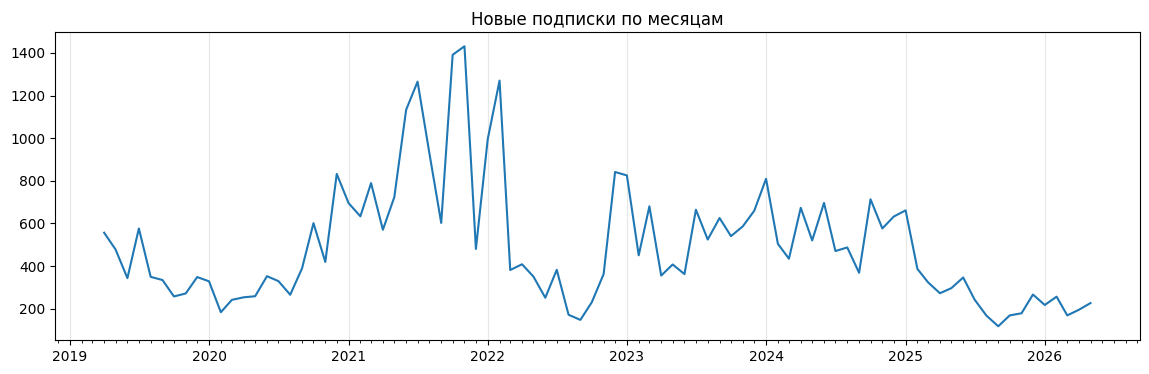

In [23]:
subs_clean["месяц_создания"] = subs_clean["Дата/время создания"].dt.to_period("M")
monthly = subs_clean.groupby("месяц_создания").size()
monthly = monthly[monthly.index < CUTOFF_M]   # неполный месяц среза не показываем

m = monthly.copy()
m.index = m.index.to_timestamp()          # Period -> обычные даты, их понимает matplotlib

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(m.index, m.values)
ax.xaxis.set_major_locator(mdates.YearLocator())            # крупные метки: раз в год
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator())           # мелкие насечки: каждый месяц
ax.grid(axis="x", alpha=0.3)
ax.set_title("Новые подписки по месяцам")
plt.show()

### Годовая динамика и честное сравнение январь–май

Основная тенденция: **подписок меньше, чек выше**. Пик привлечения — 2021 год (10,6 тыс. подписок, медианный чек 200 ₽). С 2025 года приток падает: сравнение сопоставимых периодов (январь–май) по числу новых подписок даёт **−34% в 2025 и ещё −45% в 2026**. 

При этом медианный чек вырос с 200 до 300–400 ₽ — вероятная причина: смена пресетов формы пожертвования (текущие пресеты на сайте начинаются с 500 ₽, исторические кластеры данных — 100/200 ₽).

In [24]:
year = subs_clean["Дата/время создания"].dt.year
by_year = subs_clean.groupby(year).agg(
    подписок=("ID", "count"),
    медианный_чек=("Сумма", "median"),
    средний_чек=("Сумма", "mean"),
    донаторов=("ID плательщика", "nunique"),
)
by_year.round(1)

,подписок,медианный_чек,средний_чек,донаторов
Дата/время создания,,,,
2019,3511,200.0,297.3,3074
2020,4450,200.0,256.7,3832
2021,10641,200.0,261.5,8025
2022,5788,200.0,268.6,4538
2023,6677,200.0,323.0,5190
2024,6882,200.0,480.7,5707
2025,3422,400.0,558.8,3037
2026,1124,300.0,526.8,832


In [25]:
d = subs_clean["Дата/время создания"]
jan_may = subs_clean[d.dt.month <= 5]          # только полные месяцы: январь–май

by_year_5m = jan_may.groupby(jan_may["Дата/время создания"].dt.year).agg(
    подписок=("ID", "count"),
    донаторов=("ID плательщика", "nunique"),
    медианный_чек=("Сумма", "median"),
)
by_year_5m

,подписок,донаторов,медианный_чек
Дата/время создания,,,
2019,1033,922,200.0
2020,1263,1145,200.0
2021,3410,2754,200.0
2022,3404,2745,200.0
2023,2717,2293,200.0
2024,2940,2404,200.0
2025,1938,1784,300.0
2026,1062,774,300.0


### Сезонность подключений

Больше всего новых подписок оформляется в январе, декабре и июле; меньше всего — в марте и августе–сентябре (разница между лучшим и худшим месяцем ~1,7 раза). Привлечение фонда идёт через рекламу, поэтому профиль отражает совокупность рекламных кампаний за годы, а не «природную» сезонность щедрости — без календаря кампаний интерпретируем осторожно. На правом графике скользящее среднее за 3 месяца гасит месячный шум и делает тренд читаемым: рост к пику 2021, обвал весной 2022, восстановление 2023–2024, спад с 2025.

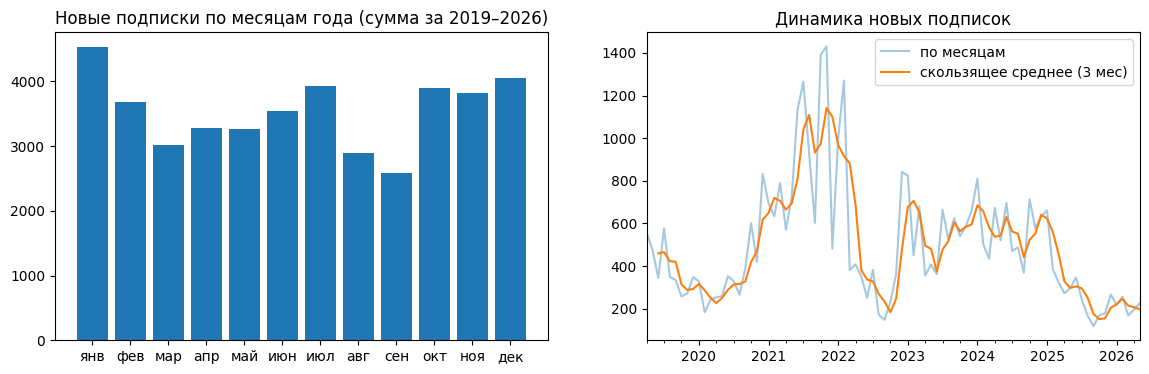

In [26]:
# Сезонность подключений и сглаженная динамика
МЕСЯЦЫ = ["янв", "фев", "мар", "апр", "май", "июн", "июл", "авг", "сен", "окт", "ноя", "дек"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4))

по_месяцам = subs_clean["Дата/время создания"].dt.month.value_counts().sort_index()
a1.bar(МЕСЯЦЫ, по_месяцам.values)
a1.set_title("Новые подписки по месяцам года (сумма за 2019–2026)")
a1.set_xlabel("")

monthly.plot(ax=a2, alpha=0.4, label="по месяцам")
monthly.rolling(3).mean().plot(ax=a2, label="скользящее среднее (3 мес)")
a2.set_title("Динамика новых подписок")
a2.set_xlabel("")
a2.legend()
plt.show()

## 5. Длительность жизни подписки

Даты отмены в выгрузке нет, поэтому конец жизни подписки определяется так:
- завершённая подписка (отменена/отклонена) — по **дате последнего платежа**;
- подписка без единого платежа — по дате создания (жизнь нулевой длины);
- живая подписка («Активна»/«Просрочена»/«В ожидании») — наблюдается до даты выгрузки. Её полная длительность ещё неизвестна: мы знаем лишь, что она прожила «как минимум N дней». Такие наблюдения называются **цензурированными** — их нельзя считать завершёнными, но нельзя и выбрасывать; корректно их учитывает survival-анализ (раздел 7).

Длительность измеряем **в днях** — это точная единица. Но списания дискретны: следующее приходит в то же число следующего месяца, то есть через 28–31 день в зависимости от длины месяца оформления, и длительность жизни в днях получается ступенчатой. Отсюда два правила:
- в когортах «прожила k месяцев» означает «прошла k циклов списания»: дни / 30,44 с округлением к ближайшему целому (отбрасывание дробной части резало бы одноплатёжные подписки пополам по длине календарного месяца);
- контрольные точки survival-кривой снимаются между списаниями, а не на границе месяца, где значение зависит от календаря, а не от поведения донатора.

В сводках раздела для читаемости дни переводятся в месяцы делением на 30,44 — среднюю длину месяца.

In [27]:
alive = subs_clean["Статус"].isin(ALIVE_STATUSES)

# правило заказчика: конец жизни = дата последнего платежа,
# а если платежей не было вообще — дата создания (жизнь нулевой длины)
subs_clean["конец_жизни"] = subs_clean["Дата/время последнего платежа"].fillna(subs_clean["Дата/время создания"])

# живые подписки ещё не кончились: их "конец" - это дата среза данных
subs_clean.loc[alive, "конец_жизни"] = CUTOFF
subs_clean["жива_на_срезе"] = alive
subs_clean["event"] = ~alive   # флаг события для survival-анализа: подписка завершилась (не цензурирована)

In [28]:
subs_clean["конец_жизни"].isna().sum() 

np.int64(0)

In [29]:
(subs_clean["конец_жизни"] < subs_clean["Дата/время создания"]).sum()

np.int64(0)

In [30]:
# Длительность жизни подписки.
# База - дни (точно, без условностей), месяцы - только для читаемых сводок.
subs_clean["дней_жизни"] = (subs_clean["конец_жизни"] - subs_clean["Дата/время создания"]).dt.days
subs_clean["месяцев_жизни"] = subs_clean["дней_жизни"] / 30.44

subs_clean["дней_жизни"].describe().round(1)

count    42495.0
mean       195.3
std        322.2
min          0.0
25%          0.0
50%         33.0
75%        241.0
max       2595.0
Name: дней_жизни, dtype: float64

**Как читать:** для «Активна» и «Просрочена» это время, прожитое к дате выгрузки, — их жизнь продолжается. Медиана по всем подпискам занижена у завершённых статусов: подписки без единого списания имеют жизнь нулевой длины, поэтому рядом дана медиана только по активированным (хотя бы одно списание). Два наблюдения:
- «Просрочена» — самые давние подписки (медиана 24 месяца). Это лояльные донаторы, у которых сейчас сбоит карта; до автоматической остановки осталось 1–2 попытки. Сегмент из 1,6 тыс. подписок ещё можно вернуть.
- Отменённые активированные подписки живут в медиане 2 месяца: решение об отмене принимается в первые месяцы. Давние подписчики отменяют редко.


In [31]:
# медиана по всем подпискам и отдельно по активированным (хотя бы одно списание):
# подписки без списаний имеют жизнь 0 и тянут медиану завершённых статусов вниз
активированные_маска = subs_clean["Кол-во платежей"] > 0

subs_clean.groupby("Статус").agg(
    подписок=("ID", "count"),
    медиана_мес=("месяцев_жизни", "median"),
    среднее_мес=("месяцев_жизни", "mean"),
).join(
    subs_clean[активированные_маска].groupby("Статус")["месяцев_жизни"]
    .median().rename("медиана_мес_активированных")
).round(1)


,подписок,медиана_мес,среднее_мес,медиана_мес_активированных
Статус,,,,
Активна,4827,19.2,21.3,19.6
В ожидании,52,4.1,4.2,4.4
Отклонена,16714,2.0,5.2,4.0
Отменена,19259,1.0,2.2,2.0
Просрочена,1643,24.3,24.9,25.0


## 6. Когортный анализ: оценочное удержание подписок

Когорта — все подписки, оформленные в одном календарном месяце. Для каждой когорты считаем, какая доля подписок прожила хотя бы 1, 2, 3… месяца. Помесячной истории платежей в выгрузке нет, поэтому активность восстанавливаем из длительности жизни: подписка считается активной в месяце k, если прожила не меньше k месяцев (полных месяцев = число пройденных циклов списания, см. раздел 5).

Важная деталь: молодые когорты видно недолго. Когорту марта 2026 к дате выгрузки можно наблюдать только 3 месяца — судить о её шестом месяце жизни рано. Такие ещё не наступившие клетки оставляем пустыми, иначе живые подписки выглядели бы умершими.

Важно: конец жизни завершённой подписки приближён датой последнего платежа (реальной даты отмены в данных нет), поэтому матрица показывает **оценочную** долю подписок, доживших до N месяцев, по доступным данным.

In [32]:
subs_clean["когорта"] = subs_clean["Дата/время создания"].dt.to_period("M")
# Полных месяцев = число пройденных циклов списания. Списание идёт в то же число следующего
# месяца, т.е. через 28-31 день; round() относит весь цикл к одному месяцу, int() резал бы
# одноплатёжные подписки пополам по длине календарного месяца оформления
subs_clean["полных_мес_жизни"] = subs_clean["месяцев_жизни"].round().astype(int)

# активированные - подписки хотя бы с одним успешным платежом (термин раздела 7).
# Определяем один раз: используются и в когортах, и в survival-анализе, и в экспорте
активированные = subs_clean[активированные_маска]

In [33]:
# Контроль подготовки: календарная когорта и полных месяцев жизни
subs_clean[["когорта", "полных_мес_жизни"]].head()

,когорта,полных_мес_жизни
0,2026-06,0
1,2026-06,0
2,2026-06,0
3,2026-06,0
4,2026-06,0


In [34]:
MAX_K = 24   # анализируем первые 24 месяца жизни когорт

def build_retention(groups, max_k=MAX_K):
    """Матрица оценочного удержания: доля подписок группы, проживших не меньше k месяцев.

    groups - последовательность (имя_когорты, горизонт_наблюдения_мес, датафрейм);
    месяцы за горизонтом наблюдения пропускаем - в матрице они остаются пустыми."""
    records = []
    for name, horizon, g in groups:
        for k in range(0, max_k + 1):
            if k > 0 and k >= horizon:
                break
            records.append({"когорта": name, "k": k,
                            "retention": (g["полных_мес_жизни"] >= k).mean()})
    return pd.DataFrame(records).pivot(index="когорта", columns="k", values="retention")

# месячные когорты: горизонт - сколько календарных месяцев когорта наблюдается до даты выгрузки
ret = build_retention(
    (str(coh), (CUTOFF_M - coh).n, g)
    for coh, g in subs_clean.groupby("когорта")
)
ret.tail(13).round(2)


k,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
когорта,,,,,,,,,,,,,,,,,,,,,
2025-06,1.0,0.81,0.67,0.60,0.55,0.52,0.49,0.47,0.43,0.43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07,1.0,0.88,0.76,0.71,0.66,0.63,0.60,0.59,0.56,0.55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08,1.0,0.86,0.80,0.71,0.66,0.65,0.62,0.60,0.57,0.55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,1.0,0.93,0.85,0.81,0.74,0.69,0.69,0.68,0.65,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10,1.0,0.89,0.82,0.77,0.71,0.70,0.68,0.64,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11,1.0,0.86,0.79,0.74,0.69,0.68,0.66,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12,1.0,0.78,0.65,0.61,0.56,0.54,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01,1.0,0.86,0.76,0.72,0.70,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-02,1.0,0.86,0.79,0.72,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


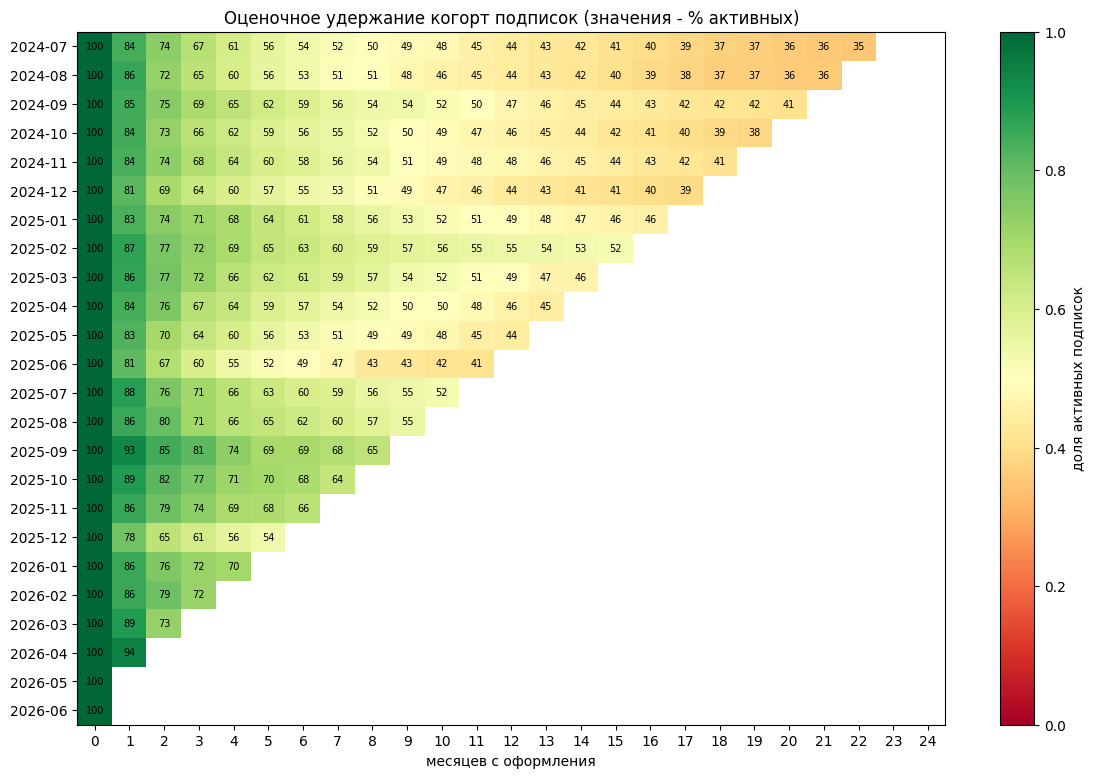

In [35]:
def plot_retention_heatmap(data, title, figsize):
    """Теплокарта удержания: строки - когорты, столбцы - месяцы жизни, значения - % живых."""
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
    ax.set_xticks(range(data.shape[1]))
    ax.set_xticklabels(data.columns)
    ax.set_yticks(range(data.shape[0]))
    ax.set_yticklabels(data.index)
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            v = data.values[r, c]
            if v == v:   # пропускаем пустые (NaN != NaN)
                ax.text(c, r, f"{v*100:.0f}", ha="center", va="center", fontsize=7)
    plt.colorbar(im, label="доля активных подписок")
    ax.set_xlabel("месяцев с оформления")
    ax.set_title(title)
    plt.show()

# последние 24 когорты
plot_retention_heatmap(ret.tail(24),
                       "Оценочное удержание когорт подписок (значения - % активных)",
                       figsize=(14, 9))


### Годовые когорты

Помесячная матрица подробна, но шумная. Укрупняем когорты до годовых: строка — год оформления подписки, столбец k — месяц жизни, значение — доля подписок этого года, проживших не меньше k месяцев. Так виден многолетний тренд качества привлечения.

In [36]:
# годовые когорты: горизонт от декабря - гарантированно наблюдаем всю когорту года
ret_year = build_retention(
    (year, (CUTOFF_M - pd.Period(f"{year}-12", "M")).n, g)
    for year, g in subs_clean.groupby(subs_clean["Дата/время создания"].dt.year)
)
ret_year.round(2)


k,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
когорта,,,,,,,,,,,,,,,,,,,,,
2019,1.0,0.50,0.30,0.23,0.18,0.15,0.13,0.12,0.10,0.09,...,0.05,0.05,0.04,0.04,0.04,0.03,0.03,0.03,0.03,0.02
2020,1.0,0.56,0.37,0.28,0.24,0.21,0.18,0.16,0.15,0.13,...,0.08,0.07,0.07,0.06,0.06,0.05,0.05,0.05,0.04,0.04
2021,1.0,0.62,0.42,0.32,0.26,0.22,0.19,0.17,0.15,0.13,...,0.08,0.07,0.07,0.06,0.06,0.06,0.05,0.05,0.05,0.05
2022,1.0,0.63,0.42,0.33,0.28,0.24,0.22,0.19,0.18,0.16,...,0.12,0.11,0.11,0.10,0.10,0.09,0.09,0.09,0.08,0.08
2023,1.0,0.69,0.51,0.44,0.38,0.35,0.33,0.31,0.29,0.28,...,0.23,0.22,0.21,0.21,0.20,0.20,0.19,0.19,0.18,0.18
2024,1.0,0.84,0.72,0.66,0.61,0.58,0.55,0.53,0.51,0.49,...,0.41,0.40,0.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025,1.0,0.84,0.75,0.69,0.65,0.61,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


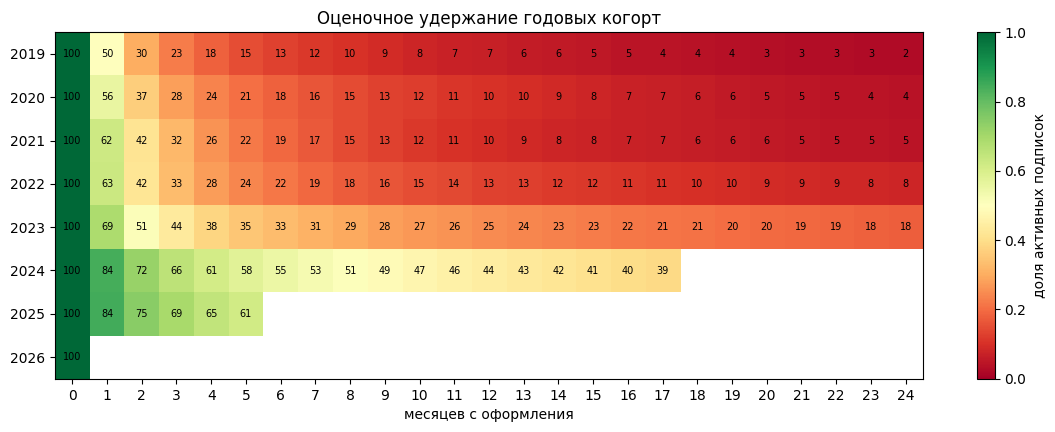

In [37]:
plot_retention_heatmap(ret_year, "Оценочное удержание годовых когорт", figsize=(14, 4.5))


Годовая матрица выше считает от **всех оформленных** подписок и потому смешивает провалы активации (первый платёж не прошёл) с собственно удержанием. Отдельно — та же матрица только по активированным (не менее одного успешного платежа): это чистое удержание. Столбец k=1 в ней равен 100% по построению (одно списание уже прошло), первый содержательный столбец — k=2, доля дошедших до второго списания.

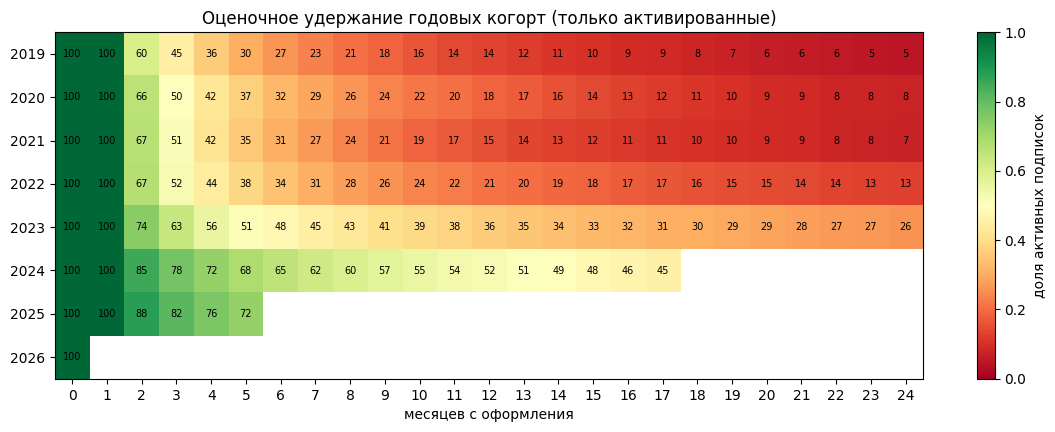

In [38]:
# то же по активированным подпискам - чистое удержание, без провалов активации
ret_year_акт = build_retention(
    (year, (CUTOFF_M - pd.Period(f"{year}-12", "M")).n, g)
    for year, g in активированные.groupby(активированные["Дата/время создания"].dt.year)
)
plot_retention_heatmap(ret_year_акт,
                       "Оценочное удержание годовых когорт (только активированные)",
                       figsize=(14, 4.5))

**Главный вывод (по оценочному удержанию) — качество привлечения выросло в разы.** 

Доля подписок, доживших до первого списания (k=1), по годовым когортам: 
- 2019 — 50%
- 2021 — 62%
- 2023 — 69%
- **2024–2025 — 84%**. 

По построению это доля активации (раздел 8 даёт те же числа) — матрица всех подписок смешивает два эффекта. Чистое удержание видно по матрице активированных: доля дошедших до второго списания (k=2) выросла с 60% (2019) до 74% (2023) и 85–88% (2024–2025); до шестого списания доходило 27% активированных 2019 года и 65% — 2024 года (когорта 2025 шестой месяц ещё не наблюдает). Улучшились оба этапа: и активация, и удержание платящих.

До 15-го месяца доживало 5% когорты-2019 и ~40% когорты-2024. Скачок 2023→2024 совпадает по времени с внедрением CRM-маркетинга фонда (welcome-цепочки, триггерные письма) — причинность недоказуема, но согласованность стоит отметить.

## 7. Survival-анализ (кривая Каплана–Майера)

### Активация и удержание — два разных процесса

Жизненный цикл подписки: оформление → первый успешный платёж (**активация**) → удержание платящего донатора. У трети оформленных подписок не прошло ни одного платежа — когда именно такая подписка перешла в терминальный статус, в данных не зафиксировано, поэтому включать их в оценку удержания некорректно. Они рассматриваются отдельно в воронке активации ниже, а survival-анализ строится **только по активированным подпискам** (не менее одного успешного платежа).

Наивная медиана длительности занижает срок жизни: живые подписки она считает завершившимися в день выгрузки. Оценка Каплана–Майера учитывает цензурированные наблюдения корректно («прожила минимум N дней и продолжает жить»). Числовые точки — в выводах ячеек ниже.

### Воронка активации

Сколько оформленных подписок доходит до первого платежа и дальше:

In [39]:
def build_activation_funnel(df, steps=(1, 2, 3, 6, 12)):
    """Воронка активации: доля оформленных подписок, достигших N успешных платежей."""
    всего = len(df)
    print(f"Оформлено подписок: {всего}")
    for n in steps:
        к = (df["Кол-во платежей"] >= n).sum()
        print(f"  >= {n:2d} платежей: {к:6d}  ({к / всего:.0%})")

build_activation_funnel(subs_clean)


Оформлено подписок: 42495
  >=  1 платежей:  28537  (67%)
  >=  2 платежей:  20668  (49%)
  >=  3 платежей:  17009  (40%)
  >=  6 платежей:  11621  (27%)
  >= 12 платежей:   7007  (16%)


45     0.740746
105    0.546106
198    0.424471
380    0.306194
Name: все активированные подписки, dtype: float64
медианное время жизни, дней: 123.0


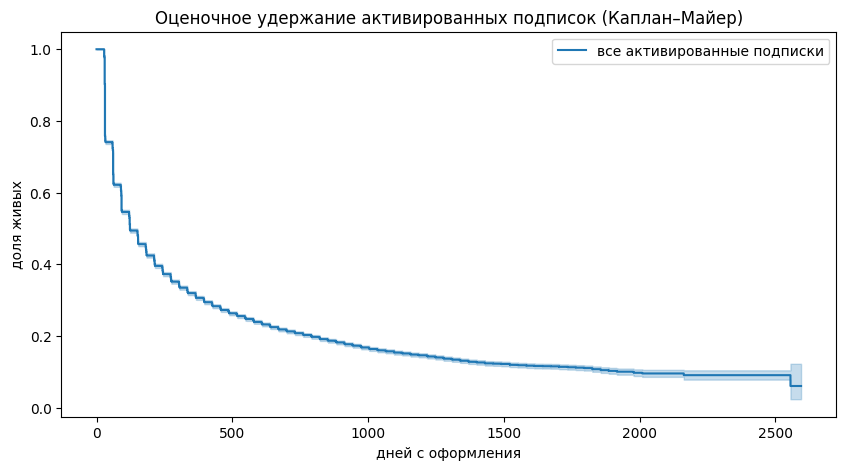

In [40]:
# кривая выживаемости строится только по АКТИВИРОВАННЫМ подпискам (см. раздел 6)
kmf = KaplanMeierFitter()
kmf.fit(активированные["дней_жизни"], event_observed=активированные["event"],
        label="все активированные подписки")

ax = kmf.plot_survival_function(figsize=(10, 5))
ax.set_xlabel("дней с оформления"); ax.set_ylabel("доля живых")
ax.set_title("Оценочное удержание активированных подписок (Каплан–Майер)")

# контрольные точки ТЗ (1/3/6/12 мес) сняты между списаниями: 45/105/198/380 дней.
# Списания дискретны (раз в 28-31 день), кривая ступенчатая; на самой ступени (30, 91 ... дней)
# значение зависит от длины календарного месяца, а не от поведения донатора
KM_POINTS = [45, 105, 198, 380]
print(kmf.predict(KM_POINTS))
print("медианное время жизни, дней:", kmf.median_survival_time_)

**Чтение результатов (по активированным подпискам):** после первого списания продолжают жить 74%, после третьего — 55%, после шестого — 42%, после двенадцатого — 31%; медианное время жизни — 123 дня (~4 месяца). Самая большая потеря — сразу после первого списания: около четверти активированных подписок делают ровно одно (воронка выше: 28 537 → 20 668). Затем ещё 19 п.п. уходят на втором и третьем списаниях, дальше спад плавный: критичное окно удержания платящего донатора — 2–3-й месяцы жизни подписки.

### Сравнение периодов привлечения

После разделения активации и удержания видно, что улучшились **оба** этапа жизненного цикла. Активация: доля оформленных подписок, дошедших до первого платежа, выросла с ~50% (2019) до ~83% (2024–2025); 2026 год не завершён — на дату среза 76%, у 152 живых подписок первое списание ещё впереди. Удержание: активированные подписки, оформленные в 2023–2026, удерживаются в **3,4 раза дольше** — медиана 306 дней против 89 у оформленных в 2019–2022; различие статистически значимо (логранк-тест, p < 0,001). В точках между списаниями: после первого списания продолжают 66% против 83%, после двенадцатого — 16% против 47%. Часть «пятикратного» разрыва из смешанной оценки объяснялась активацией, но и чистое удержание платящих выросло более чем втрое.

2019-2022 медиана: 89.0 дн. | после 1/3/6/12 списаний: [0.66, 0.42, 0.28, 0.16]
2023-2026 медиана: 306.0 дн. | после 1/3/6/12 списаний: [0.83, 0.68, 0.58, 0.47]


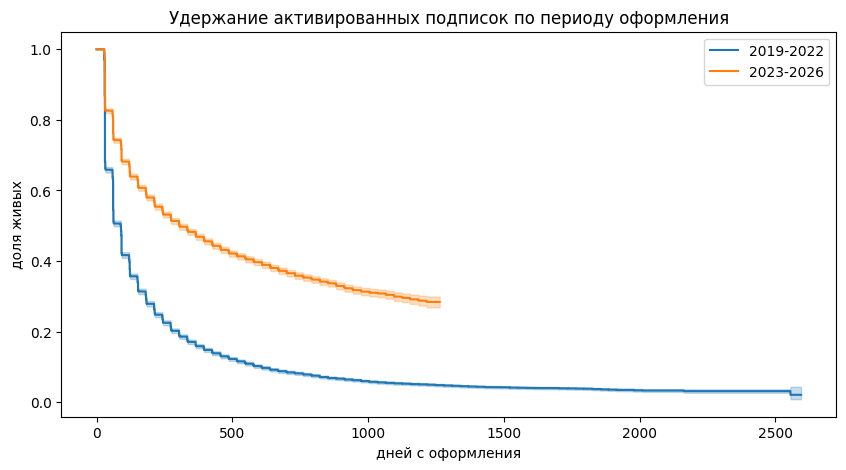

In [41]:
old = активированные["Дата/время создания"].dt.year <= 2022
ax = None
for label, mask in [("2019-2022", old), ("2023-2026", ~old)]:
    kmf = KaplanMeierFitter()
    kmf.fit(активированные.loc[mask, "дней_жизни"],
            активированные.loc[mask, "event"], label=label)
    ax = kmf.plot_survival_function(ax=ax, figsize=(10, 5))
    print(label, "медиана:", kmf.median_survival_time_, "дн. |",
          "после 1/3/6/12 списаний:", kmf.predict(KM_POINTS).round(2).tolist())
ax.set_xlabel("дней с оформления"); ax.set_ylabel("доля живых")
ax.set_title("Удержание активированных подписок по периоду оформления")
plt.show()

In [42]:
res = logrank_test(
    активированные.loc[old, "дней_жизни"], активированные.loc[~old, "дней_жизни"],
    активированные.loc[old, "event"], активированные.loc[~old, "event"],
)
print("p-value:", res.p_value)

p-value: 0.0


### Два типа терминальных статусов (упрощённый анализ)

Каждый тип завершения анализируется отдельно, второй тип при этом выступает цензурированием — это упрощение задачи конкурирующих рисков (строгий метод — Cumulative Incidence / Aalen–Johansen — для проекта избыточен), поэтому формулировки осторожные.

Каждая кривая показывает долю подписок, **ещё не завершённых по данной причине**: чем ниже кривая, тем больше потерь этого типа.

- в первые ~7 месяцев больше потерь от добровольных отмен: они сконцентрированы на первых списаниях, и кривая «Отменена» идёт ниже;
- на 213-й день кривые пересекаются, дальше главным становится техническое завершение (отклонение карты): за второй год жизни подписки оно забирает ещё 13% активированных подписок, добровольные отмены — 6%. Риск отклонения карты со временем не снижается, склонность к добровольной отмене после первого года заметно ослабевает.

Практическое следствие: в первые полгода ключевая работа — коммуникация (ценность регулярной поддержки), дальше — платёжная механика (обновление карт, подписки в статусе «Просрочена»).

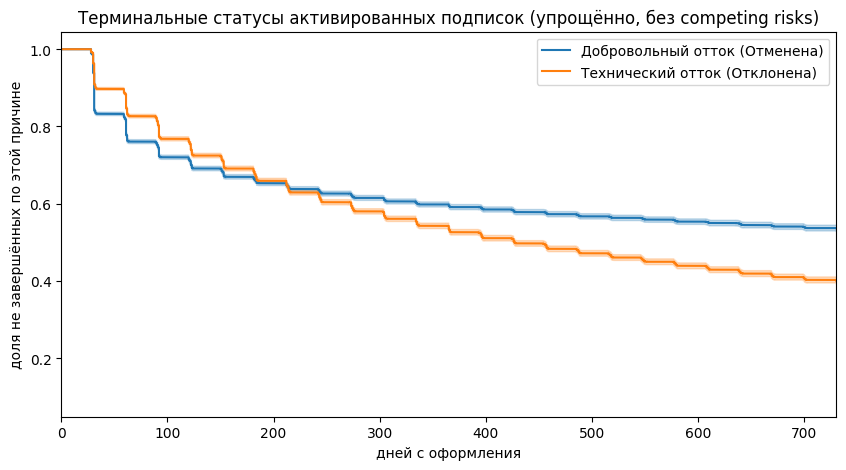

In [43]:
ax = None
for label, status in [("Добровольный отток (Отменена)", "Отменена"),
                      ("Технический отток (Отклонена)", "Отклонена")]:
    kmf = KaplanMeierFitter()
    kmf.fit(активированные["дней_жизни"],
            event_observed=(активированные["Статус"] == status), label=label)
    ax = kmf.plot_survival_function(ax=ax, figsize=(10, 5))
ax.set_xlim(0, 730)   # первые 2 года, дальше хвост малоинформативен
ax.set_xlabel("дней с оформления"); ax.set_ylabel("доля не завершённых по этой причине")
ax.set_title("Терминальные статусы активированных подписок (упрощённо, без competing risks)")
plt.show()

## 8. Структура оттока

У трети подписок не прошло ни одного списания. Разбираем нулевые подписки, вводим классификацию оттока и проверяем его сезонность.

In [44]:
subs_clean.loc[subs_clean["Кол-во платежей"] == 0, "Статус"].value_counts()

Статус
Отменена      8922
Отклонена     4766
Активна        130
Просрочена     125
В ожидании      15
Name: count, dtype: int64

In [45]:
zero = subs_clean[subs_clean["Кол-во платежей"] == 0]
pd.crosstab(
    zero["Дата/время создания"].dt.year,
    zero["Статус"],
    normalize="index",   # каждая строка (год) нормируется к 1: видим доли статусов внутри года
).round(2)

Статус,Активна,В ожидании,Отклонена,Отменена,Просрочена
Дата/время создания,,,,,
2019,0.00,0.00,0.37,0.63,0.00
2020,0.00,0.00,0.35,0.65,0.00
2021,0.00,0.00,0.34,0.66,0.00
2022,0.00,0.00,0.36,0.64,0.00
2023,0.00,0.00,0.35,0.65,0.00
2024,0.00,0.00,0.24,0.70,0.06
2025,0.00,0.01,0.35,0.56,0.08
2026,0.49,0.04,0.25,0.17,0.04


In [46]:
dead = subs_clean["Статус"].isin(DEAD_STATUSES)
subs_clean["тип_оттока"] = np.select(
    [
        dead & (subs_clean["Кол-во платежей"] == 0),   # умерла, не заплатив ни разу
        subs_clean["Статус"] == "Отменена",             # жила и была отменена вручную
        subs_clean["Статус"] == "Отклонена",            # жила и умерла от проблем с картой
    ],
    ["не запустилась", "добровольный", "технический"],
    default="жива/ретраится",
)
subs_clean["тип_оттока"].value_counts()

тип_оттока
не запустилась    13688
технический       11948
добровольный      10337
жива/ретраится     6522
Name: count, dtype: int64

**Классификация оттока** (мёртвая подписка с 0 платежей ≠ добровольный уход):

- «не запустилась» — 13 688 (38% смертей): первый платёж не прошёл;
- «технический» — 11 948 (33%): списания шли, подписка остановлена после трёх неудачных попыток (проблема карты);
- «добровольный» — 10 337 (29%): списания шли, подписка отменена по запросу.

**Два из трёх потерянных донаторов теряются по техническим причинам, а не по решению уйти.** Незапустившиеся на 65% завершены отменой (63–66% во все годы 2019–2023 — похоже на естественное поведение донаторов после неудачной попытки, а не на автоматическую очистку со стороны фонда).

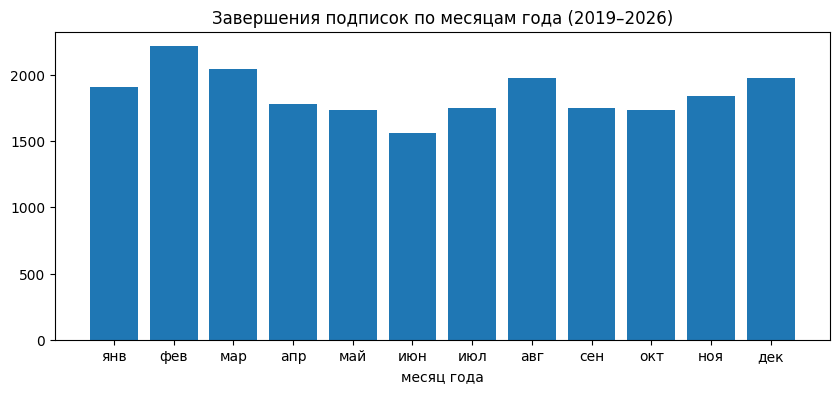

In [47]:
# Завершения подписок по месяцам года
завершено = subs_clean[subs_clean["тип_оттока"].isin(["добровольный", "технический"])]

по_месяцам_оттока = завершено["конец_жизни"].dt.month.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(МЕСЯЦЫ, по_месяцам_оттока.values)
ax.set_title("Завершения подписок по месяцам года (2019–2026)")
ax.set_xlabel("месяц года")
plt.show()

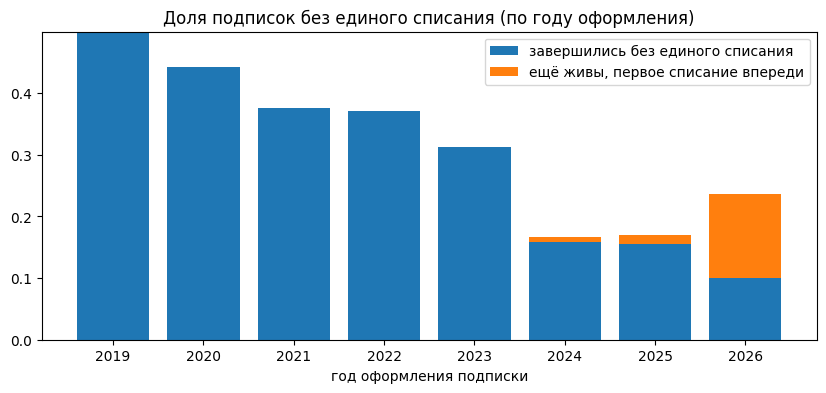

Дата/время создания
2019    0.500
2020    0.443
2021    0.376
2022    0.371
2023    0.313
2024    0.167
2025    0.169
2026    0.236
dtype: float64

In [48]:
# Доля подписок без единого списания среди созданных, по годам.
# Нулевые подписки делим на завершённые и ещё живые: у живых первое списание может пройти позже
год_создания = subs_clean["Дата/время создания"].dt.year
создано_в_год = subs_clean.groupby(год_создания).size()

нули = subs_clean.loc[subs_clean["Кол-во платежей"] == 0].copy()
нули["год"] = нули["Дата/время создания"].dt.year
срез = (нули.groupby(["год", "жива_на_срезе"]).size()
        .unstack(fill_value=0)
        .reindex(index=создано_в_год.index, columns=[False, True], fill_value=0))

доля_завершились = срез[False] / создано_в_год
доля_живых = срез[True] / создано_в_год

fig, ax = plt.subplots(figsize=(10, 4))
годы = доля_завершились.index.astype(str)
ax.bar(годы, доля_завершились.values, label="завершились без единого списания")
ax.bar(годы, доля_живых.values, bottom=доля_завершились.values,
       label="ещё живы, первое списание впереди")
ax.set_title("Доля подписок без единого списания (по году оформления)")
ax.set_xlabel("год оформления подписки")
ax.legend()
plt.show()

(доля_завершились + доля_живых).round(3)

**Сезонность оттока и брак первого платежа.** Смерти распределены по календарю ровно (±20%): отток определяется возрастом подписки, а не сезоном; небольшой пик в феврале–марте — отражение декабрьско-январского пика подключений, сдвинутое на типичную длительность жизни.

**Доля подписок без единого платежа упала с 50% (2019) до 17% (2024–2025)** — брак первого списания снижен втрое, и это главный источник различия между периодами привлечения. Столбик 2026 года разложен на две части: 10% подписок уже завершились без платежа, ещё 13% живы — их первое списание впереди, поэтому итоговая доля года будет ниже сегодняшних 24%.

## 9. RFM-сегментация донаторов

Уровень анализа — донатор (`ID плательщика`); метрики собираются по всем его подпискам.

- **R (давность)** — дней с последнего платежа. Пороги заданы от логики ежемесячных списаний: до 60 дней — платёж мог пройти в последние два цикла, донатор активен; 61–180 — списания недавно прекратились, зона риска; более 180 — донатор ушёл. Перцентильные пороги здесь не подходят: за 7 лет большая часть базы естественно ушла, и квантили описывали бы прошлое, а не текущее состояние.
- **F (частота)** — всего платежей: 1 — попробовал; 2–6 — платил до полугода; 7 и более — постоянный донатор.
- **M (деньги)** — суммарный сбор с донатора, три равные группы (терцили).

9 240 донаторов без единого успешного платежа в сетку не входят — это отдельный сегмент воронки оформления, а не отток.

In [49]:
subs_clean["сбор"] = subs_clean["Сумма"] * subs_clean["Кол-во платежей"]

def build_donor_mart(df):
    """Витрина донаторов: одна строка = плательщик, агрегаты по всем его подпискам."""
    return df.groupby("ID плательщика").agg(
        подписок=("ID", "count"),
        платежей=("Кол-во платежей", "sum"),
        сбор=("сбор", "sum"),
        последний_платёж=("Дата/время последнего платежа", "max"),
        первая_подписка=("Дата/время создания", "min"),
        жив=("жива_на_срезе", "max"),
    )

donors = build_donor_mart(subs_clean)
len(donors)


31104

In [50]:
def build_rfm(donors, cutoff=CUTOFF):
    """RFM-разметка платившим донаторам (бизнес-пороги: R - 60/180 дней, F - 1/2-6/7+, M - терцили)."""
    payers = donors[donors["платежей"] > 0].copy()
    payers["R_дней"] = (cutoff - payers["последний_платёж"]).dt.days
    payers["R"] = pd.cut(payers["R_дней"], bins=[-1, 60, 180, 10**9],
                         labels=["активный (≤60)", "риск (61-180)", "ушедший (>180)"])
    payers["F"] = pd.cut(payers["платежей"], bins=[0, 1, 6, 10**9],
                         labels=["разовый (1)", "пробующий (2-6)", "постоянный (7+)"])
    payers["M"] = pd.qcut(payers["сбор"], 3, labels=["низкий", "средний", "высокий"])
    return payers

payers = build_rfm(donors)
print("платившие:", len(payers), "| не платившие:", (donors["платежей"] == 0).sum())
payers[["R", "F", "M"]].apply(lambda col: col.value_counts())


платившие: 21864 | не платившие: 9240


,R,F,M
активный (≤60),4536.0,NaN,NaN
высокий,NaN,NaN,7208.0
низкий,NaN,NaN,8136.0
постоянный (7+),NaN,9057.0,NaN
пробующий (2-6),NaN,7422.0,NaN
разовый (1),NaN,5385.0,NaN
риск (61-180),872.0,NaN,NaN
средний,NaN,NaN,6520.0
ушедший (>180),16456.0,NaN,NaN


In [51]:
rfm = payers.groupby(["R", "F"], observed=True).agg(
    донаторов=("сбор", "size"),
    сбор_всего=("сбор", "sum"),
    средний_сбор=("сбор", "mean"),
)
rfm["доля_людей_%"] = (rfm["донаторов"] / len(payers) * 100).round(1)
rfm["доля_денег_%"] = (rfm["сбор_всего"] / payers["сбор"].sum() * 100).round(1)
rfm.round(0)

донаторов  сбор_всего  средний_сбор  \
R              F                                                      
активный (≤60) разовый (1)            120     82625.0         689.0   
               пробующий (2-6)        591   1492258.0        2525.0   
               постоянный (7+)       3825  38441175.0       10050.0   
риск (61-180)  разовый (1)             91     45081.0         495.0   
               пробующий (2-6)        196    504572.0        2574.0   
               постоянный (7+)        585   4222700.0        7218.0   
ушедший (>180) разовый (1)           5174   1740954.0         336.0   
               пробующий (2-6)       6635   6902020.0        1040.0   
               постоянный (7+)       4647  20697869.0        4454.0   

                                доля_людей_%  доля_денег_%  
R              F                                            
активный (≤60) разовый (1)               0.0           0.0  
               пробующий (2-6)           3.0           2.0  
               постоянный (7+)          18.0          52.0  
риск (61-180)  разовый (1)               0.0           0.0  
               пробующий (2-6)           1.0           1.0  
               постоянный (7+)           3.0           6.0  
ушедший (>180) разовый (1)              24.0           2.0  
               пробующий (2-6)          30.0           9.0  
               постоянный (7+)          21.0          28.0

### Сегменты и работа с ними

| Сегмент | R × F | Людей | Доля денег | Работа с сегментом |
|:--|:--|--:|--:|:--|
| Ядро | активный × 7+ | 3 825 (18%) | 52% | Приоритет удержания: персональная благодарность, годовой отчёт об использовании средств, умеренная частота рассылок. Потеря донатора из ядра обходится фонду дороже всего |
| Растущие | активный × 1–6 | 711 (3%) | 2% | Довести до привычки: в первые 60 дней показать результат пожертвования (истории подопечных), подчеркнуть ценность регулярности |
| Под угрозой | риск × 7+ | 585 (3%) | 6% | Немедленная реактивация: списания прекратились недавно; уведомление о проблеме с платежом и предложение обновить карту |
| Спящие постоянные | ушедший × 7+ | 4 647 (21%) | 28% | Отдельная возвратная кампания: это бывшие постоянные донаторы; сегмент с наибольшим потенциалом реактивации — первый приоритет CRM-кампаний |
| Ушедшие разовые и пробующие | ушедший × 1–6 | 11 809 (54%) | 11% | Недорогие массовые касания, значительные затраты на сегмент не окупятся |
| Не запустившиеся | вне сетки | 9 240 (30% всех донаторов, вне базы плативших) | 0% | Не отток, а несработавшее оформление: доработка первого платежа, письмо с предложением повторить оплату другой картой |

Постоянные донаторы (7+ платежей) суммарно — 41% людей и **86% всех денег**: ценность донатора определяется постоянством, а не размером разового чека.

### Ключевые показатели фонда (весь период)

Пункт 2 ТЗ: базовые бизнес-показатели за весь период выгрузки (по решению заказчика — 2019–2026, а не за отдельный год). Считаются по витрине донаторов, поэтому идут после RFM. Все «сейчас» отсчитываются от даты среза 18.06.2026.

- **Всего собрано и всего списаний** — сумма «Сумма × Кол-во платежей» и сумма счётчика списаний по всем подпискам.
- **Средний номинал подписки (341 ₽)** — среднее поле «Сумма»: сколько донаторы выбирают в форме; каждая подписка весит одинаково.
- **Средний успешный платёж (311 ₽)** — всего собрано / всего списаний: сколько приносит одно списание. Он ниже номинала, значит, подписки с крупной суммой в среднем делают меньше списаний, чем дешёвые.
- **LTV платившего донатора** — исторический (накопленный за всю жизнь в базе), не прогноз: средний = всего собрано / число плативших; медианный показывает, что половина плативших принесла не больше 1 000 ₽. Разрыв между средним и медианой — концентрация денег в ядре, которую количественно даёт ABC-анализ ниже.
- **Живая платившая база** — донаторы, у которых на дату среза есть подписка в живом статусе и хотя бы одно списание за историю. Живые подписки без единого списания (оформлены в последний месяц, первое списание впереди) в неё не входят.


In [52]:
# LTV (исторический) и ключевые бизнес-числа
print("Всего собрано:", f"{donors['сбор'].sum():,.0f} ₽")
print("Всего списаний:", subs_clean["Кол-во платежей"].sum())
print("Средний номинал подписки:", f"{subs_clean['Сумма'].mean():,.0f} ₽")
print("Средний успешный платёж:", f"{subs_clean['сбор'].sum() / subs_clean['Кол-во платежей'].sum():,.0f} ₽")
print("LTV платившего донатора (средний):", f"{payers['сбор'].mean():,.0f} ₽")
print("LTV платившего донатора (медианный):", f"{payers['сбор'].median():,.0f} ₽")
print("Живая платившая база сейчас:", (donors["жив"] & (donors["платежей"] > 0)).sum(), "донаторов")

Всего собрано: 74,129,254 ₽
Всего списаний: 238277
Средний номинал подписки: 341 ₽
Средний успешный платёж: 311 ₽
LTV платившего донатора (средний): 3,390 ₽
LTV платившего донатора (медианный): 1,000 ₽
Живая платившая база сейчас: 5258 донаторов


## 10. ABC-анализ (Парето)

Классы по накопленной доле сбора: A — первые 80% денег, B — до 95%, C — остальное. База — платившие донаторы (21,9 тыс.): человек без единого успешного платежа — не «донатор класса C», а несостоявшаяся активация. Крупные донаторы включены: их исключение исказило бы оценку концентрации пожертвований.

**Итог: 25% плативших донаторов (класс A, 5,4 тыс. человек) приносят 80% всех сборов.** Порог входа в класс A — всего 3 300 ₽ суммарно за историю (≈ 200 ₽ × 17 месяцев): в «ценные» попадают за счёт постоянства, а не размера чека — вывод согласуется с RFM.

In [53]:
def build_abc(donors):
    """ABC-классы по кумулятивной доле сборов: A - первые 80% денег, B - до 95%, C - остальное."""
    abc = donors.sort_values("сбор", ascending=False).copy()
    abc["кум_доля_денег"] = abc["сбор"].cumsum() / abc["сбор"].sum()
    abc["класс"] = pd.cut(abc["кум_доля_денег"], bins=[0, 0.8, 0.95, 1],
                          labels=["A", "B", "C"], include_lowest=True)
    return abc

abc = build_abc(payers)   # база - платившие (та же, что в RFM и SQL-версии)
abc.groupby("класс", observed=True).agg(
    донаторов=("сбор", "size"),
    сбор=("сбор", "sum"),
    мин_сбор=("сбор", "min"),
)


,донаторов,сбор,мин_сбор
класс,,,
A,5411,59300956.00,3300.0
B,6207,11121512.00,950.0
C,10246,3706785.82,1.0


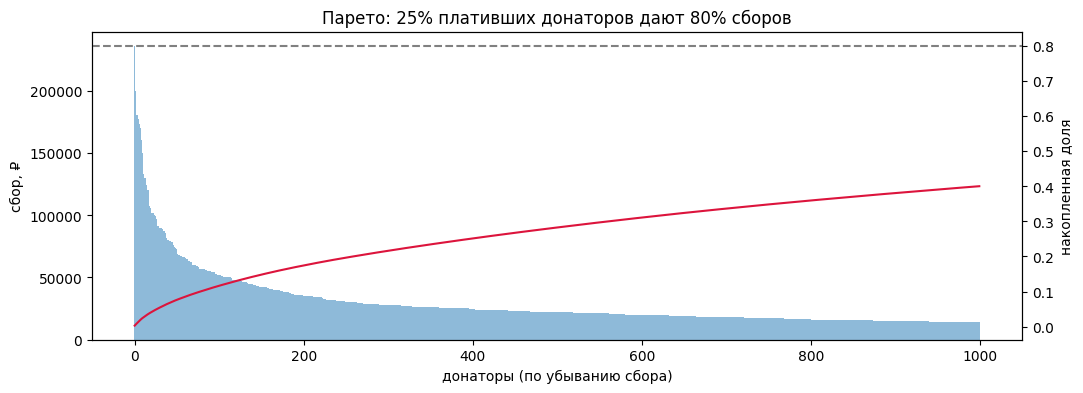

In [54]:
top = abc.head(1000).reset_index(drop=True)   # первая тысяча, дальше хвост неинформативен
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(top.index, top["сбор"], width=1, alpha=0.5)
ax2 = ax.twinx()                              # вторая ось Y для кумулятивной линии
ax2.plot(top.index, top["кум_доля_денег"], color="crimson")
ax2.axhline(0.8, ls="--", color="gray")
ax.set_xlabel("донаторы (по убыванию сбора)"); ax.set_ylabel("сбор, ₽")
ax2.set_ylabel("накопленная доля")
ax.set_title("Парето: 25% плативших донаторов дают 80% сборов")
plt.show()

## 11. SQL-слой (DuckDB): перекрёстная проверка

Ключевые расчёты продублированы на SQL поверх того же датасета (DuckDB читает датафрейм напрямую). Все контрольные цифры сошлись с pandas-версией: сводки по статусам и годам, таблица донаторов, RFM-сетка, ABC-классы (обе версии считают ABC по платившим донаторам). Для ABC при ничьих использован построчный фрейм окна (`ROWS BETWEEN`) — соответствует построчному `cumsum` pandas.

Повторяющиеся подзапросы вынесены в представления: `донаторы` (агрегаты по плательщику) и `пары` (self-join переоформлений, окно до 180 дней).

In [55]:
import duckdb

con = duckdb.connect()

# duckdb не понимает Period-колонки - убираем их по типу, а не по списку имён
period_cols = [c for c in subs_clean.columns if isinstance(subs_clean[c].dtype, pd.PeriodDtype)]
sql_view = subs_clean.drop(columns=period_cols)
con.register("Cloud_Payments", sql_view)

# Представления для запросов ниже (вместо повторения одинаковых CTE)
con.sql("""
CREATE OR REPLACE VIEW донаторы AS
SELECT
    "ID плательщика",
    COUNT(*) AS "Кол-во подписок",
    SUM("Кол-во платежей") AS "Всего платежей",
    SUM("Сумма"*"Кол-во платежей") AS "Сумма всех списаний",
    MAX("Дата/время последнего платежа") AS "Дата/время последнего платежа"
FROM Cloud_Payments
GROUP BY "ID плательщика"
""")

con.sql("""
CREATE OR REPLACE VIEW пары AS
SELECT
    m."ID плательщика",
    m."ID" AS старая, n."ID" AS новая,
    m."Статус",
    m."Сумма" AS сумма_старой, n."Сумма" AS сумма_новой,
    CAST(n."Дата/время создания" AS DATE) - CAST(m."конец_жизни" AS DATE) AS разрыв_дн
FROM Cloud_Payments m
JOIN Cloud_Payments n
    ON m."ID плательщика" = n."ID плательщика"
    AND n."ID" != m."ID"
    AND (CAST(n."Дата/время создания" AS DATE) - CAST(m."конец_жизни" AS DATE)) BETWEEN 0 AND 180
WHERE m."тип_оттока" IN ('добровольный', 'технический')
""")

In [56]:
con.sql("DESCRIBE Cloud_Payments").df()

,column_name,column_type,null,key,default,extra
0,ID,VARCHAR,YES,None,None,None
1,Дата/время создания,TIMESTAMP_NS,YES,None,None,None
2,Статус,VARCHAR,YES,None,None,None
3,Сумма,DOUBLE,YES,None,None,None
4,Валюта,VARCHAR,YES,None,None,None
5,Периодичность,VARCHAR,YES,None,None,None
6,Описание,VARCHAR,YES,None,None,None
7,ID плательщика,VARCHAR,YES,None,None,None
8,Кол-во платежей,BIGINT,YES,None,None,None
9,Дата/время последнего платежа,TIMESTAMP_NS,YES,None,None,None


In [57]:
con.sql("""
Select
"Статус",
COUNT(*) as "Кол-во подписок",
COUNT(DISTINCT "ID плательщика") as "Кол-во подписчиков"
from  Cloud_Payments
GROUP BY "Статус"
Order by "Статус"
""").df()


,Статус,Кол-во подписок,Кол-во подписчиков
0,Активна,4827,4176
1,В ожидании,52,52
2,Отклонена,16714,12762
3,Отменена,19259,15013
4,Просрочена,1643,1315


In [58]:
con.sql("""
select 
SUM("Сумма"*"Кол-во платежей") as "Сумма всех списаний",
SUM("Кол-во платежей") as "Всего списаний",
SUM("Сумма"*"Кол-во платежей")/SUM("Кол-во платежей") as "Средний успешный платёж",
avg("Сумма") as "Средний номинал подписки",
MEDIAN("Сумма") as "Медиана номинала"
from Cloud_Payments
""").df()

,Сумма всех списаний,Всего списаний,Средний успешный платёж,Средний номинал подписки,Медиана номинала
0,74129253.82,238277.0,311.105368,341.048166,200.0


In [59]:
con.sql("""
SELECT
EXTRACT(YEAR FROM "Дата/время создания") as "Год",
COUNT(*) as "Кол-во подписок",
COUNT(DISTINCT "ID плательщика") as "Кол-во подписчиков",
MEDIAN("Сумма") as "Медиана чека"
FROM Cloud_Payments
GROUP BY "Год"
ORDER BY "Год"
""").df()

,Год,Кол-во подписок,Кол-во подписчиков,Медиана чека
0,2019,3511,3074,200.0
1,2020,4450,3832,200.0
2,2021,10641,8025,200.0
3,2022,5788,4538,200.0
4,2023,6677,5190,200.0
5,2024,6882,5707,200.0
6,2025,3422,3037,400.0
7,2026,1124,832,300.0


In [60]:
con.sql("""
SELECT *
FROM донаторы
ORDER BY "Сумма всех списаний" 
DESC LIMIT 5
""").df()

,ID плательщика,Кол-во подписок,Всего платежей,Сумма всех списаний,Дата/время последнего платежа
0,PID_0c805ad28c0f,4,116.0,235500.0,2026-06-11 14:05:58
1,PID_7baae73ac7f2,1,5.0,200000.0,2026-06-06 22:54:19
2,PID_7658d88f2574,1,36.0,180000.0,2024-12-05 00:22:40
3,PID_2f1f912f078a,2,19.0,180000.0,2026-06-13 16:48:14
4,PID_08f50d5b2763,2,51.0,177500.0,2026-06-02 12:23:11


In [61]:
con.sql(f"""
SELECT
CASE
        WHEN (DATE '{CUTOFF.date()}' - CAST("Дата/время последнего платежа" AS DATE)) <= 60 THEN  'активный (≤60)'
        WHEN (DATE '{CUTOFF.date()}'- CAST("Дата/время последнего платежа" AS DATE)) <= 180 THEN 'риск (61-180)'
        ELSE 'ушедший (>180)'
END AS R,
CASE
        WHEN "Всего платежей" = 1 THEN  'разовый (1)'
        WHEN "Всего платежей" BETWEEN  2 AND 6 THEN 'пробующий (2-6)'
        ELSE 'постоянный (7+)'
END AS F,
Count ("ID плательщика") AS "Подписчики",
SUM("Сумма всех списаний") as "Сумма всех списаний"
FROM донаторы
WHERE "Всего платежей">0
Group by R,F
ORDER BY "Сумма всех списаний" 

""").df()

,R,F,Подписчики,Сумма всех списаний
0,риск (61-180),разовый (1),91,45081.00
1,активный (≤60),разовый (1),120,82625.00
2,риск (61-180),пробующий (2-6),196,504572.00
3,активный (≤60),пробующий (2-6),591,1492258.00
4,ушедший (>180),разовый (1),5174,1740953.82
5,риск (61-180),постоянный (7+),585,4222700.00
6,ушедший (>180),пробующий (2-6),6635,6902020.00
7,ушедший (>180),постоянный (7+),4647,20697869.00
8,активный (≤60),постоянный (7+),3825,38441175.00


In [62]:
con.sql("""
WITH Доли AS (
SELECT
"ID плательщика",
"Сумма всех списаний",
SUM("Сумма всех списаний") OVER (ORDER BY "Сумма всех списаний" DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)/SUM("Сумма всех списаний") OVER () AS "кум_доля"
FROM донаторы
WHERE "Всего платежей">0)

SELECT
CASE
        WHEN "кум_доля" <= 0.8 then 'A'
        WHEN "кум_доля" <= 0.95 then 'B'
        ELSE 'C'
END AS "Класс",
count(*) AS "Кол-во людей",
SUM("Сумма всех списаний")  as "Всего денег",
ROUND(SUM("Сумма всех списаний") * 100.0 / SUM(SUM("Сумма всех списаний")) OVER (), 1) AS "Доля денег, %"
FROM Доли
GROUP BY "Класс"
""").df()

,Класс,Кол-во людей,Всего денег,"Доля денег, %"
0,A,5411,59300956.00,80.0
1,B,6207,11121512.00,15.0
2,C,10246,3706785.82,5.0


In [63]:
con.sql("""
Select
"тип_оттока",
"Статус"
from  Cloud_Payments
group by "тип_оттока","Статус"
Order by "тип_оттока","Статус"
""").df()

,тип_оттока,Статус
0,добровольный,Отменена
1,жива/ретраится,Активна
2,жива/ретраится,В ожидании
3,жива/ретраится,Просрочена
4,не запустилась,Отклонена
5,не запустилась,Отменена
6,технический,Отклонена


### Переоформления подписок (self-join)

Механика сервиса не позволяет донатору изменить действующую подписку: по FAQ сайта смена суммы возможна только через отмену и оформление новой подписки, а в пользовательском кабинете CloudPayments (my.cloudpayments.ru) доступно единственное действие — отмена (вход выполняется по номеру карты; замена карты не предусмотрена). Следовательно, часть «оттока» — служебные переоформления. Ищем пары: завершённая подписка → новая подписка того же плательщика в течение 60 дней.

In [64]:
con.sql("""
SELECT COUNT(DISTINCT старая) as "Переоформлено подписок", "Статус" AS "Статус завершённой подписки"
FROM пары
WHERE разрыв_дн <= 60
Group by 2
""").df()


,Переоформлено подписок,Статус завершённой подписки
0,561,Отменена
1,789,Отклонена


In [65]:
con.sql("""
SELECT
"Статус" AS "Статус завершённой подписки",
CASE
        WHEN "сумма_новой" > "сумма_старой" THEN 'новая больше'
        WHEN "сумма_новой" = "сумма_старой" THEN 'та же'
        ELSE 'меньше'
END AS "Сумма новой подписки относительно старой",
COUNT(DISTINCT старая) as "Переоформлено подписок"
from пары
WHERE разрыв_дн <= 60
Group by 1, 2
""").df()


,Статус завершённой подписки,Сумма новой подписки относительно старой,Переоформлено подписок
0,Отклонена,та же,539
1,Отменена,та же,344
2,Отклонена,меньше,166
3,Отменена,меньше,136
4,Отменена,новая больше,126
5,Отклонена,новая больше,189


Порог 60 дней — допущение, поэтому проверяем чувствительность оценки к ширине окна (30/60/90/180 дней). Считаем уникальные завершённые подписки, у которых нашёлся кандидат в каждом окне:

In [66]:
con.sql("""
SELECT
    "Статус" AS "Статус завершённой подписки",
    COUNT(DISTINCT CASE WHEN разрыв_дн <= 30 THEN старая END) AS "окно 30 дн",
    COUNT(DISTINCT CASE WHEN разрыв_дн <= 60 THEN старая END) AS "окно 60 дн",
    COUNT(DISTINCT CASE WHEN разрыв_дн <= 90 THEN старая END) AS "окно 90 дн",
    COUNT(DISTINCT старая) AS "окно 180 дн"
FROM пары
GROUP BY 1
""").df()


,Статус завершённой подписки,окно 30 дн,окно 60 дн,окно 90 дн,окно 180 дн
0,Отклонена,505,789,951,1264
1,Отменена,391,561,697,937


**Итог парного анализа:** найдено 1 350 **кандидатов на переоформление** — 5,4% отмен и 6,6% отклонений. В обоих типах доминирует переоформление с той же суммой (вероятно, смена карты); при смене суммы повышений и понижений примерно поровну в обоих типах (суммарно 315 против 302). Обратная сторона важнее: **для 93% технически завершённых подписок новая подписка того же плательщика в 60-дневном окне не найдена** (возврат позже 60 дней, через другой канал или разовым пожертвованием данные не показывают) — что поддерживает рекомендацию об уведомлении о сбое списания.

**Чувствительность к окну:** число кандидатов растёт с шириной окна плавно, без естественного «плато» (см. таблицу выше), а структура пар устойчива — во всех окнах преобладает новая подписка с той же суммой. Базовым оставляем окно 60 дней: короткий разрыв похож на служебное переоформление (смену карты или суммы), а возврат через несколько месяцев корректнее считать самостоятельной реактивацией — это другое явление.

## 12. Экспорт витрин для Power BI

Все витрины выгружает `export_marts()`:

- `подписки.csv` — одна строка = подписка: статус, сумма, платежи, длительность жизни, тип оттока;
- `донаторы.csv` — платившие донаторы с RFM-метками и ABC-классом;
- `когорты.csv` — матрица оценочного удержания помесячных когорт в длинном формате;
- `когорты_годовые.csv` — годовые когорты по двум базам (все оформленные / только активированные);
- `выживаемость.csv` — кривые Каплана–Майера по пяти группам.

В обе когортные витрины добавлен размер когорты (`подписок`): без него укрупнение месячных когорт до годовых в Power BI даёт невзвешенное среднее и расходится с расчётом ноутбука. Правильная мера — `SUM(retention × подписок) / SUM(подписок)`; для годовой картины проще брать готовую витрину `когорты_годовые.csv`, где строка года обрывается там, где наблюдаются ещё не все её месячные когорты.

In [67]:
def export_marts(subs_clean, payers, abc, ret, годовые, активированные, old):
    """Выгружает витрины для Power BI: подписки, донаторы, когорты, кривые выживаемости.

    годовые - {название базы: матрица годовых когорт}."""
    POWERBI_DIR.mkdir(exist_ok=True)

    # 1) подписки: одна строка = подписка
    export = subs_clean[[
        "ID", "ID плательщика", "Дата/время создания", "Статус", "Сумма",
        "Кол-во платежей", "сбор", "дней_жизни", "тип_оттока", "is_major", "конец_жизни",
    ]]
    export.to_csv(POWERBI_DIR / "подписки.csv", index=False, encoding="utf-8-sig")
    print("подписки.csv:        ", len(export), "строк")

    # 2) донаторы: платившие с RFM-метками и ABC-классом
    donors_export = payers[["подписок", "платежей", "сбор", "R", "F", "M"]].join(abc["класс"])
    donors_export.to_csv(POWERBI_DIR / "донаторы.csv",
                         encoding="utf-8-sig", index_label="ID плательщика")
    print("донаторы.csv:        ", len(donors_export), "строк")

    # 3) когорты: длинный формат + размер когорты (нужен для взвешенных сводок в Power BI)
    def в_длинный(матрица, размеры):
        long = (матрица.reset_index()
                .melt(id_vars="когорта", var_name="месяц_жизни", value_name="retention")
                .dropna())
        long["подписок"] = long["когорта"].map(размеры)
        return long

    размеры_мес = subs_clean.groupby("когорта").size()
    размеры_мес.index = размеры_мес.index.astype(str)          # ключ матрицы - строка
    cohort_long = в_длинный(ret, размеры_мес)
    cohort_long.to_csv(POWERBI_DIR / "когорты.csv", index=False, encoding="utf-8-sig")
    print("когорты.csv:         ", len(cohort_long), "строк")

    базы = {"все": subs_clean, "активированные": активированные}
    годовые_long = pd.concat([
        в_длинный(матрица, базы[имя].groupby(базы[имя]["Дата/время создания"].dt.year).size())
        .assign(база=имя)
        for имя, матрица in годовые.items()
    ])
    годовые_long.to_csv(POWERBI_DIR / "когорты_годовые.csv", index=False, encoding="utf-8-sig")
    print("когорты_годовые.csv: ", len(годовые_long), "строк")

    # 4) кривые выживаемости: пять групп (маска old - границы периодов из раздела 7)
    группы = [
        ("все активированные", активированные["дней_жизни"],           активированные["event"]),
        ("эпоха 2019-2022",    активированные.loc[old, "дней_жизни"],  активированные.loc[old, "event"]),
        ("эпоха 2023-2026",    активированные.loc[~old, "дней_жизни"], активированные.loc[~old, "event"]),
        ("добровольный отток", активированные["дней_жизни"],           активированные["Статус"] == "Отменена"),
        ("технический отток",  активированные["дней_жизни"],           активированные["Статус"] == "Отклонена"),
    ]
    kmf = KaplanMeierFitter()
    куски = []
    for группа, длительности, факт_смерти in группы:
        kmf.fit(длительности, event_observed=факт_смерти)
        s = kmf.survival_function_.reset_index()
        s.columns = ["день", "вероятность"]
        s["группа"] = группа
        куски.append(s)
    выживаемость = pd.concat(куски)
    выживаемость.to_csv(POWERBI_DIR / "выживаемость.csv", index=False, encoding="utf-8-sig")
    print("выживаемость.csv:    ", len(выживаемость), "строк")

export_marts(subs_clean, payers, abc, ret,
             {"все": ret_year, "активированные": ret_year_акт},
             активированные, old)

подписки.csv:         42495 строк
донаторы.csv:         21864 строк
когорты.csv:          1851 строк
когорты_годовые.csv:  300 строк
выживаемость.csv:     6683 строк


## 13. Выводы и рекомендации

### Основные выводы

1. **Модель привлечения качественно изменилась.** В 2019–2022 реклама приводила много подписчиков низкого качества: каждый второй не доходил до первого списания, а из дошедших 33–40% делали ровно одно. Улучшились оба этапа жизненного цикла: активация — доля дошедших до первого платежа выросла с ~50% до ~83% (2024–2025; 2026 год не завершён); удержание — активированные подписки, оформленные с 2023 года, удерживаются в 3,4 раза дольше (медиана 306 дней против 89), а доля активированных подписок, дошедших до второго списания, выросла с 60% до 85–88%.
2. **Главный риск — сокращение притока.** К сопоставимому периоду прошлого года новых подписок меньше на 34% (2025) и ещё на 45% (2026). Качественная база пополняется медленнее, чем стареет.
3. **Отток преимущественно технический.** 38% потерь — несработавший первый платёж, 33% — отклонение карты у действующей подписки и только 29% — отмена по решению донатора. Добровольные отмены концентрируются в первый месяц жизни подписки; после года основная причина потерь — прекращение работы карты.
4. **Ценность донатора определяется постоянством, а не размером чека.** Донаторы с 7 и более платежами — 41% людей и 86% всех сборов; 25% плативших донаторов (класс A) дают 80% денег, при этом порог входа в класс A — всего 3 300 ₽ за всю историю.
5. **Часть видимого оттока — не отток.** Около 6% завершённых подписок имеют кандидата на переоформление тем же донатором в 60-дневном окне (смена суммы или карты возможна только через отмену). Обратная сторона: для 93% технически завершённых подписок новая подписка в этом окне не найдена.

### Рекомендации

1. **Приток.** Разобраться в причинах падения привлечения 2025–2026 (бюджеты и эффективность рекламных кампаний): при текущем качестве удержания каждый привлечённый донатор ценнее, чем когда-либо.
2. **Просроченные подписки.** Настроить уведомление «обновите карту» для сегмента «Просрочена»: ~1,5 тыс. подписок лояльных донаторов находятся в одном-двух сбоях от автоматической остановки.
3. **Сбой списания.** Если уведомление о неудачном списании отсутствует — внедрить: сейчас самостоятельно переоформляются только 6,6% технически завершённых подписок.
4. **Первый платёж.** Сейчас каждый шестой оформивший подписку не проходит первое списание (за весь период наблюдения — каждый третий). Письмо с предложением повторить оплату другой картой возвращает людей, уже готовых жертвовать.
5. **Сегментная работа (RFM).** Возвратная кампания по «спящим постоянным» (4,6 тыс. человек, 28% исторических сборов; сегмент с наибольшим потенциалом реактивации); персональное сопровождение ядра и крупных донаторов (158 человек).
6. **Управление подпиской.** Дать донатору возможность изменить сумму и карту без отмены подписки: текущая механика создаёт лишние действия для лояльных донаторов и искажает статистику отмен.
7. **Причины отмен.** Добавить короткий опрос при отмене — единственный способ узнать причины добровольного оттока, который концентрируется в первый месяц.
8. **Аномальные плательщики.** Уточнить природу двух технических плательщиков (219 подписок с суммами 38–99 ₽ за 2026 год; 116 подписок по 17 ₽ за 2023–2024) и риски для отчётности: первый обеспечивает ~20% «новых подписок» 2026 года, второй — 6% сегмента «Просрочена».

### Ограничения анализа

- Выгрузка покрывает только карточные подписки CloudPayments: разовые пожертвования, SMS и переводы не видны. Пункт ТЗ «переход от разовых пожертвований к регулярным» исключён: данных о разовых пожертвованиях нет.
- Платёж при оформлении подписки в выгрузке не отражён: по данным, «Кол-во платежей» считает только автосписания, первое из которых проходит через месяц после создания (у подписок с одним платежом дата платежа всегда на 28–31 день позже создания; у свежих активных подписок счётчик равен 0). Если это подтвердится, «0 платежей» означает «не дожила до первого регулярного списания», а не «первый платёж не прошёл», а накопленные сборы занижены на сумму платежей при оформлении. Требует подтверждения заказчиком.
- Списания дискретны (раз в 28–31 день, в то же число месяца), поэтому длительность жизни в днях ступенчатая. Полные месяцы считаются округлением к ближайшему циклу списания, контрольные точки кривой Каплана–Майера сняты между списаниями (45/105/198/380 дней): значения ровно на 30/91/183/365 днях зависели бы от длины календарного месяца оформления, а не от поведения донатора.
- Помесячная история списаний отсутствует — удержание реконструировано по длительности жизни подписки; списания с пропусками огрубляют оценку.
- Даты отмены в выгрузке нет — конец жизни приближен датой последнего платежа (смещение ~1 месяц назад от фактического события). Смещение асимметрично: среди активированных подписок 2019–2022 цензурировано (живо) лишь 4%, среди 2023–2026 — 40%, поэтому длительности старого периода занижены сильнее и измеренный разрыв удержания (×3,4) — скорее верхняя оценка; направление вывода это не меняет.
- Источник привлечения подписки в данных отсутствует — сегментация по каналам и интерпретация всплесков без календаря кампаний невозможны.
- Два аномальных плательщика (технические каналы) сохранены в данных с флагом; их природа требует подтверждения фондом.